<a href="https://colab.research.google.com/github/pattmikyu/wine-quality-classification/blob/main/graficos_tech_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importando as bibliotecas necessárias para análises
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('WineQT.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


A variável de qualidade deverá ser transformada em uma classificação
binária

In [ ]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [ ]:
#quais notas possuimos na coluna quality (primeiro vamos transformar em int)
df['quality'] = df['quality'].astype(int)

unique_n= df['quality'].unique()
print(unique_n)

[5 6 7 4 8 3]


In [ ]:
# média (soma de todas as notas dividida pela quantidade)
media = df['quality'].mean()
print(f"Média: {media:.2f}")

# mediana (o valor que divide os dados exatamente ao meio)
mediana = df['quality'].median()
print(f"Mediana: {mediana}")

# moda (a nota que mais se repete)
# O [0] no final é necessário porque pode existir mais de uma moda, então pegamos a primeira
moda = df['quality'].mode()[0]
print(f"Moda: {moda}")

Média: 5.66
Mediana: 6.0
Moda: 5


com essa conclusão, podemos manter a nota para vinhos de alta qualidade como >= 7. Pois, se a moda é 5.0 e a média é 5.66, significa que o vinho 'padrão' da base é nota 5.
Como a mediana é 6.0, pelo menos 5% dos vinhos são nota 6 para baixo.
Como as notas estao indo de 1 em 1, para diferenciar dos vinhos mediocres, a próxima nota seria 7.

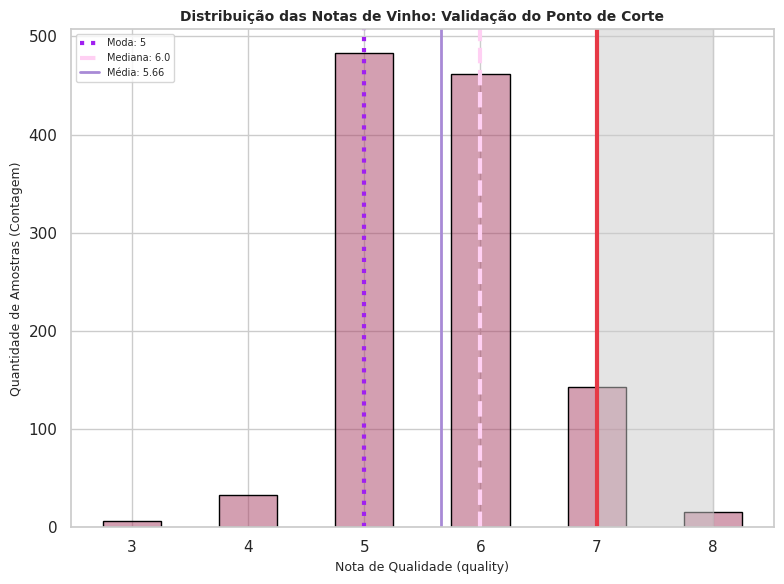

In [ ]:
n_alta_qualidade = 7
#vamos verificar através de um histograma
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
#discrete = true porque os números das notas são inteiros
ax = sns.histplot(data=df, x='quality', discrete=True, color='#A94064', shrink= 0.5 , edgecolor='black', alpha=0.5)
#linha da moda
plt.axvline(moda, color='#A020F0', linestyle=':', linewidth=3, label=f'Moda: {moda}')
#linha da mediana
plt.axvline(mediana, color='#FFD0F3', linestyle='--', linewidth=3, label=f'Mediana: {mediana}')
#linha da média
plt.axvline(media, color='#A88AD6', linestyle='-', linewidth=2, label=f'Média: {media:.2f}')

# adicionar a linha de corte de alta qualidade
plt.axvline(n_alta_qualidade, color='#e63946', linestyle='-', linewidth=3)


# área de alta qualidade (cinza)
plt.axvspan(n_alta_qualidade, df['quality'].max(), color='#CBCBCB', alpha=0.5)


# títulos e rótulos
plt.title('Distribuição das Notas de Vinho: Validação do Ponto de Corte', fontsize=10, fontweight='bold')
plt.xlabel('Nota de Qualidade (quality)', fontsize=9)
plt.ylabel('Quantidade de Amostras (Contagem)', fontsize=9)
plt.xticks(sorted(df['quality'].unique())) # garante que todas as notas apareçam no eixo x
plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

o grafico mostra, visualmente, que a distruibuição das notas 7 e 8 são realmente acima da média, tornando os vinhos com essa nota de alta qualidade.

In [ ]:
# Conta a quantidade de valores nulos em cada coluna
valores_nulos = df.isnull().sum()
print(valores_nulos)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
#criar uma nova coluna transformando os valores de alta qualidade em 1 e o resto 0 (binário)
df['alta_qualidade'] = np.where(df['quality'] >= 7,1,0)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,alta_qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [ ]:
#para que o modelo não erre, retirarei a coluna quality
retirada_quality = ['quality']
if 'Id' in df.columns:
    retirada_quality.append('Id')

df = df.drop(columns = retirada_quality)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,alta_qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


Eliminamos as colunas antigas. Conhecido como prevenção de data leakage (vazamento de dados). Se você deixar a coluna quality na base, o modelo vai aprender que "se quality é 7, então o alvo é 1", sem dar importância para o pH, álcool, acidez, etc

EDA - Análise Exploratória de Dados

Investigação da distribuição das variáveis

/tmp/ipykernel_1788/757426705.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='alta_qualidade', palette=['#FFB6C1', '#722F37'])


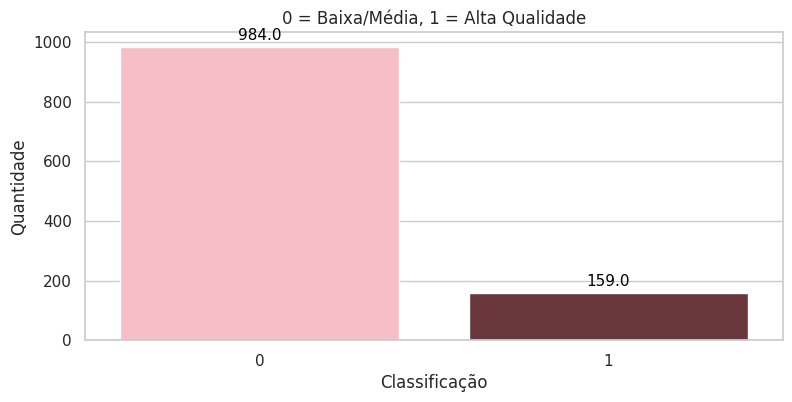

alta_qualidade
0    86.09
1    13.91
Name: proportion, dtype: float64


In [ ]:
# Configura o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Gráfico de contagem
plt.figure(figsize=(9, 4))
ax = sns.countplot(data=df, x='alta_qualidade', palette=['#FFB6C1', '#722F37'])
plt.title('0 = Baixa/Média, 1 = Alta Qualidade')
plt.xlabel('Classificação')
plt.ylabel('Quantidade')

# Adiciona os números em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Percentual
print(df['alta_qualidade'].value_counts(normalize=True).round(4) * 100)

Identificamos que aproximadamente 14% da base é de vinho de alta qualidade

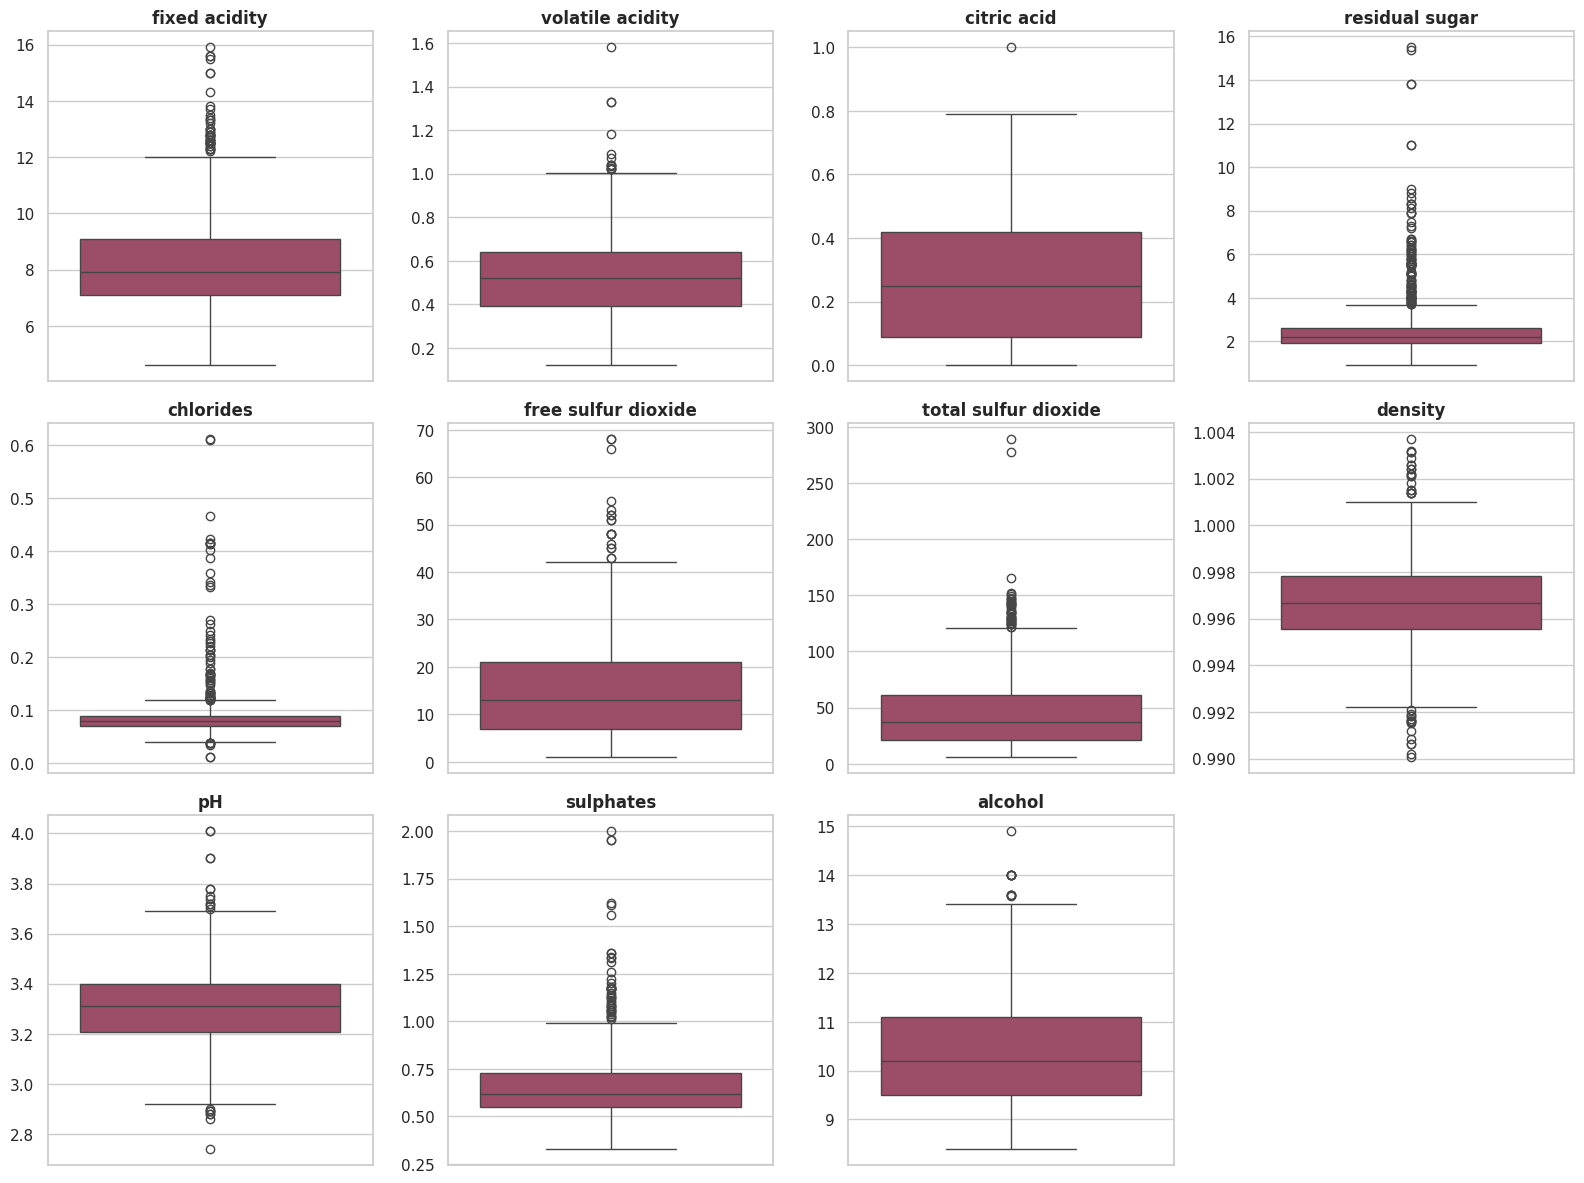

In [ ]:
# Pega todas as colunas, exceto a variável 'alta_qualidade'
features = df.drop(columns=['alta_qualidade']).columns

# Cria uma grade de gráficos (Boxplots)
plt.figure(figsize=(16, 12))
for i, col in enumerate(features):
    plt.subplot(3, 4, i+1) # Grade de 3 linhas por 4 colunas
    sns.boxplot(y=df[col], color='#A94064')
    plt.title(col, fontsize=12, fontweight='bold')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Identificação de outliers nos outros parâmetros de vinhos, sem levar em consideração a qualidade dele

Agora, faremos cálculos de correlações

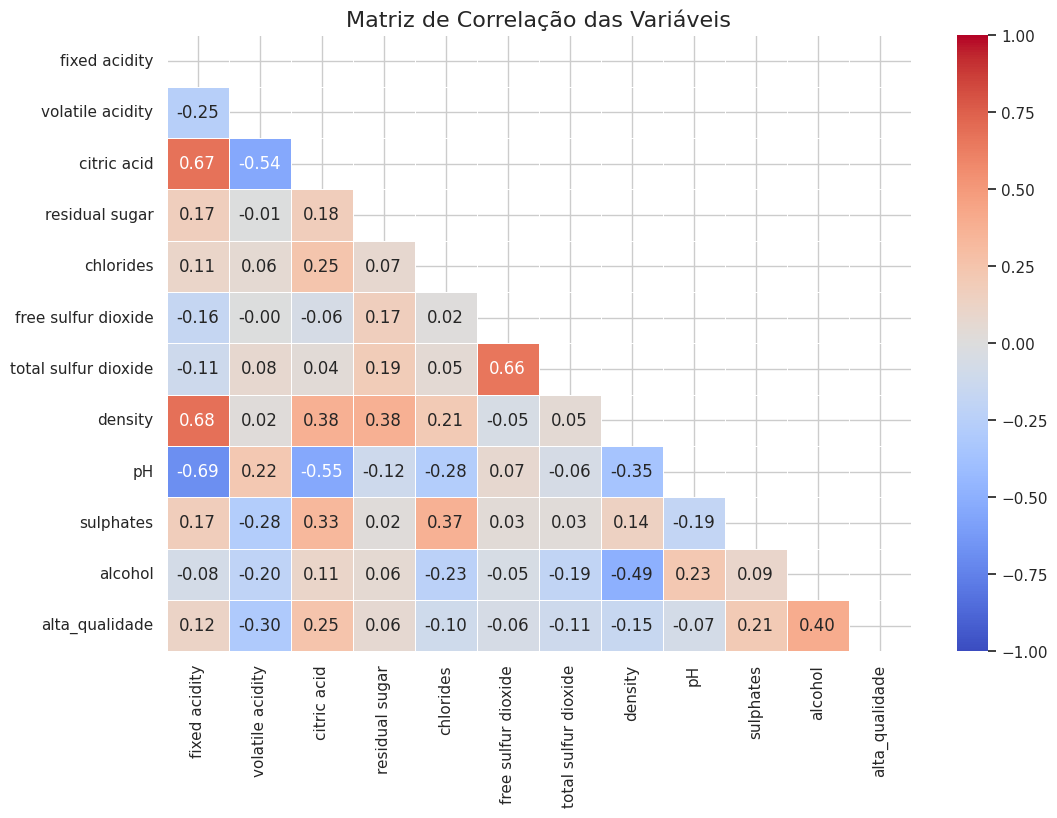

In [ ]:
plt.figure(figsize=(12, 8))
# Calcula a correlação de Pearson
matriz_correlacao = df.corr()

# Máscara para esconder a metade superior do gráfico (que é espelhada)
mask = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

# Plota o mapa de calor
sns.heatmap(matriz_correlacao, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação das Variáveis', fontsize=16)
plt.show()

Usamos o heatmap para identificar quais variáveis são úteis. Por exemplo: com +0.40, o alcool indica quando o vinho é bom. Do mesmo modo, com -0.30, a acidez volátil indica quando o vinho é ruim.
Uma vez que, a correlação positiva é próxima de +1. A correlação é negativa quando próxima de -1 e a correlação é neutra quando próxima de 0.

In [ ]:
#validar se faz sentido este cálculo
correlation = df['alcohol'].corr(df['alta_qualidade'])
print(f"A correlação entre alcohol e quality é: {correlation:.2f}")

A correlação entre alcohol e quality é: 0.40


In [ ]:
from scipy.stats import pearsonr

# Calculando a correlação de Pearson e o valor-p
correlation_coefficient, p_value = pearsonr(df['alcohol'], df['alta_qualidade'])

print(f"Coeficiente de Correlação de Pearson: {correlation_coefficient:.2f}")
print(f"Valor-p: {p_value:.3f}")

# Interpretando o valor-p
alpha = 0.05 # Nível de significância comum

if p_value < alpha:
    print(f"Com um valor-p de {p_value:.3f} (menor que {alpha}), rejeitamos a hipótese nula.\nIsso sugere que a correlação entre 'alcohol' e 'quality' é estatisticamente significativa.")
else:
    print(f"Com um valor-p de {p_value:.3f} (maior que {alpha}), não rejeitamos a hipótese nula.\nNão há evidência estatística suficiente para afirmar que a correlação entre 'alcohol' e 'quality' é significativa.")

Coeficiente de Correlação de Pearson: 0.40
Valor-p: 0.000
Com um valor-p de 0.000 (menor que 0.05), rejeitamos a hipótese nula.
Isso sugere que a correlação entre 'alcohol' e 'quality' é estatisticamente significativa.


/tmp/ipykernel_1788/1876994887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alta_qualidade', y='alcohol', palette=['#8d99ae', '#722F37'])


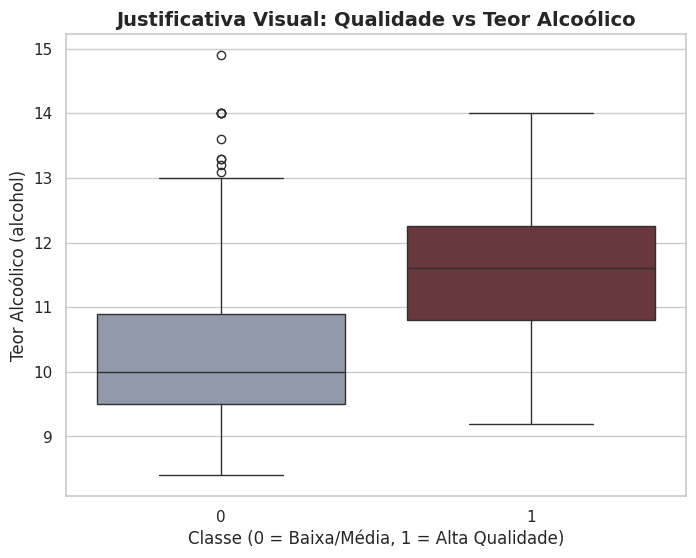

In [ ]:
plt.figure(figsize=(8, 6))
# Cruzando a classe (X) com a variável química (Y)
sns.boxplot(data=df, x='alta_qualidade', y='alcohol', palette=['#8d99ae', '#722F37'])

plt.title('Justificativa Visual: Qualidade vs Teor Alcoólico', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0 = Baixa/Média, 1 = Alta Qualidade)', fontsize=12)
plt.ylabel('Teor Alcoólico (alcohol)', fontsize=12)

plt.show()

O boxplot dos vinhos de alta qualidade está acima do boxplot dos vinhos comum quando comparado ao alcóol deles

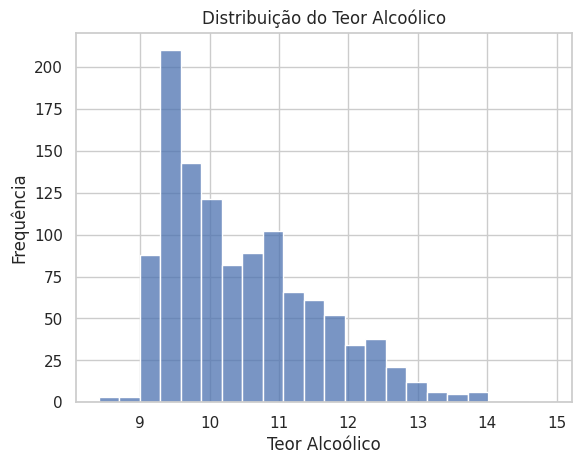

In [ ]:
sns.histplot(df['alcohol'])
plt.title('Distribuição do Teor Alcoólico')
plt.xlabel('Teor Alcoólico')
plt.ylabel('Frequência')
plt.show()